In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cv_tuning import prepare_train_test_data, CV_FOLDS
from kernels import KERNEL_REGISTRY
from optimizers import (
    robbins_monro_svm, adagrad_svm, adam_svm,
    predict_rm, print_rm_eval_report,
    tune_optimizer_joint_cv, fit_best, run_svm_experiments,
    RM_PARAM_GRID, ADAGRAD_PARAM_GRID, ADAM_PARAM_GRID,
)

data = prepare_train_test_data(filepath='../data/ridings.csv')
X_train     = data['X_train_proc']
X_test      = data['X_test_proc']
y_train     = data['y_train'].values
y_test      = data['y_test'].values
y_train_svm = data['y_train_svm']
y_test_svm  = data['y_test_svm']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'Class balance    : {y_train.mean():.2%} Liberal (train)')

Training samples : 273
Test samples     : 69
Features         : 20
Class balance    : 49.82% Liberal (train)


# Robbins-Monro SVM — Optimization
### Soft-margin SVM using stochastic subgradient descent (Robbins-Monro)
### in the dual/representer form with kernels..

**loss minimised:**

$$
L(\boldsymbol{\alpha}, b) = \frac{1}{n}\sum_{j=1}^{n} \max\!\big\{0,\; 1 - y_j\,\big(\mathbf{K}_j^\top \boldsymbol{\alpha} - b\big)\big\} + \lambda \|\mathbf{w}\|^2
$$

where $\mathbf{w} = \sum_i \alpha_i \,\varphi(\mathbf{x}_i)$ and $\mathbf{K}$ is the Gram matrix for the chosen kernel.

## 1 Baseline: RM with Default Hyperparameters


In [2]:
N_EPOCHS = 200

# some defaults per kernel
DEFAULT_KP = {
    'linear':  {},
    'rbf':     {'gamma': 0.1},
    'poly':    {'degree': 2, 'gamma': 1.0, 'coef0': 1.0},
    'sigmoid': {'gamma': 0.01, 'coef0': 0.0},
}

baseline = {}
for kernel_name in KERNEL_REGISTRY:
    res = robbins_monro_svm(
        X_train, y_train_svm, X_test, y_test_svm,
        kernel_name=kernel_name,
        kernel_params=DEFAULT_KP[kernel_name],
        lambda_reg=0.01, n_epochs=N_EPOCHS, eta0=0.1, decay=0.01,
    )
    baseline[kernel_name] = res

# --- Table ---
bl_df = pd.DataFrame([
    {
        'Kernel': k,
        'Kernel Params': str(DEFAULT_KP[k]) if DEFAULT_KP[k] else '—',
        'Train Acc': f"{r['train_acc_history'][-1]:.4f}",
        'Test Acc':  f"{r['test_acc_history'][-1]:.4f}",
        'Time (s)':  f"{r['fit_time_s']:.2f}",
    }
    for k, r in baseline.items()
])
bl_df.index = bl_df.index + 1
bl_df.index.name = '#'
bl_df.style.set_caption('Table 1 — RM SVM baseline (default hyperparameters, 200 epochs)')

,Kernel,Kernel Params,Train Acc,Test Acc,Time (s)
#,,,,,
1,linear,—,0.7985,0.7971,0.17
2,rbf,{'gamma': 0.1},0.8242,0.7391,0.17
3,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.8132,0.7971,0.14
4,sigmoid,"{'gamma': 0.01, 'coef0': 0.0}",0.6337,0.6377,0.14


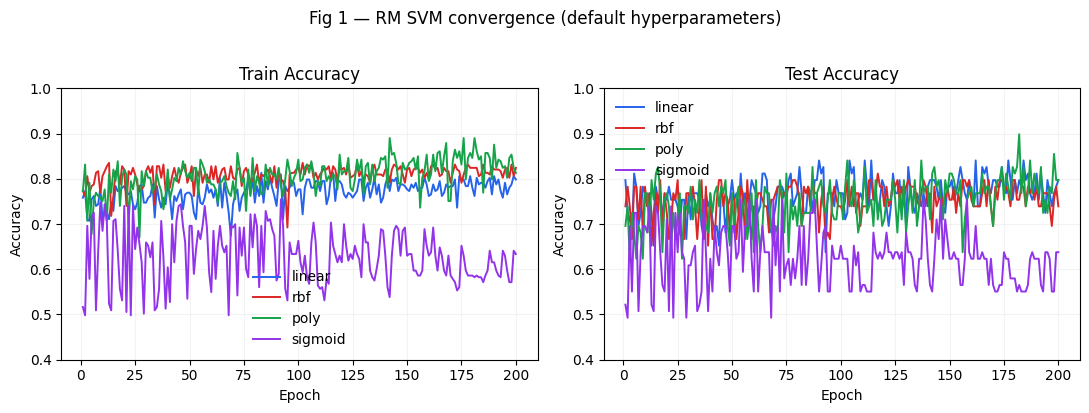

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {'linear': '#2563eb', 'rbf': '#dc2626', 'poly': '#16a34a', 'sigmoid': '#9333ea'}

for k, res in baseline.items():
    epochs = range(1, len(res['train_acc_history']) + 1)
    axes[0].plot(epochs, res['train_acc_history'], label=k, color=colors[k], lw=1.4)
    axes[1].plot(epochs, res['test_acc_history'],  label=k, color=colors[k], lw=1.4)

for ax, title in zip(axes, ['Train Accuracy', 'Test Accuracy']):
    ax.set(xlabel='Epoch', ylabel='Accuracy', title=title)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.15)
    ax.set_ylim(0.4, 1.0)

fig.suptitle('Fig 1 — RM SVM convergence (default hyperparameters)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## 2 Joint Cross-Validation: Kernel × Optimizer Tuning
We jointly search over **kernel hyperparameters** (from `KERNEL_REGISTRY`) and **RM optimizer settings** ($\lambda$, $\eta_0$, decay, epochs).

In [4]:
print(f'RM grid size     : {len(RM_PARAM_GRID)} combos per kernel setting')
total = sum(len(KERNEL_REGISTRY[k]["param_grid"]) for k in KERNEL_REGISTRY)
print(f'Kernel settings  : {total} total across all kernels')
print(f'Total configs    : {total * len(RM_PARAM_GRID)} × 5 folds\n')

joint = tune_optimizer_joint_cv(
    robbins_monro_svm, X_train, y_train,
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

RM grid size     : 36 combos per kernel setting
Kernel settings  : 42 total across all kernels
Total configs    : 1512 × 5 folds

  linear    combos tested:   36  best_cv so far: 0.7909  [10s]
  rbf       combos tested:  216  best_cv so far: 0.8242  [59s]
  poly      combos tested: 1188  best_cv so far: 0.8425  [324s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8425  [420s]


## Best Configuration per Kernel
### with tuned hyperparameters

In [5]:
df = joint['results_df'].copy()

# Best row per kernel (by mean CV)
idx_best = df.groupby('kernel')['mean_cv'].idxmax()
best_per_kernel = df.loc[idx_best].sort_values('mean_cv', ascending=False).reset_index(drop=True)

display_df = best_per_kernel[['kernel', 'kernel_params', 'lambda_reg', 'eta0', 'decay', 'n_epochs', 'mean_cv', 'std_cv']].copy()
display_df.columns = ['Kernel', 'Kernel Params', 'λ', 'η₀', 'Decay', 'Epochs', 'Mean CV Acc', 'Std CV']
display_df['Mean CV Acc'] = display_df['Mean CV Acc'].map('{:.4f}'.format)
display_df['Std CV']      = display_df['Std CV'].map('±{:.4f}'.format)
display_df.index = display_df.index + 1
display_df.index.name = '#'
display_df.style.set_caption('Table 2 — Best RM configuration per kernel (5-fold CV)')

,Kernel,Kernel Params,λ,η₀,Decay,Epochs,Mean CV Acc,Std CV
#,,,,,,,,
1,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.010000,0.010000,0.010000,50,0.8425,±0.0443
2,rbf,{'gamma': 0.1},0.001000,0.100000,0.010000,50,0.8242,±0.0426
3,linear,{},0.010000,0.010000,0.010000,100,0.7909,±0.0410
4,sigmoid,"{'gamma': 0.1, 'coef0': 0.0}",0.001000,0.010000,0.010000,100,0.7359,±0.0629


### Top 10 Configurations Overall

In [6]:
top10 = df.head(10)[['kernel', 'kernel_params', 'lambda_reg', 'eta0', 'decay', 'n_epochs', 'mean_cv', 'std_cv']].copy()
top10.columns = ['Kernel', 'Kernel Params', 'λ', 'η₀', 'Decay', 'Epochs', 'Mean CV Acc', 'Std CV']
top10['Mean CV Acc'] = top10['Mean CV Acc'].map('{:.4f}'.format)
top10['Std CV']      = top10['Std CV'].map('±{:.4f}'.format)
top10.index = range(1, 11)
top10.index.name = 'Rank'
top10.style.set_caption('Table 3 — Top 10 configurations by CV accuracy')

,Kernel,Kernel Params,λ,η₀,Decay,Epochs,Mean CV Acc,Std CV
Rank,,,,,,,,
1,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.010000,0.010000,0.010000,50,0.8425,±0.0443
2,rbf,{'gamma': 0.1},0.001000,0.100000,0.010000,50,0.8242,±0.0426
3,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.010000,0.010000,0.100000,50,0.8242,±0.0393
4,poly,"{'degree': 2, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.100000,0.010000,100,0.8240,±0.0349
5,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.010000,0.010000,0.010000,100,0.8205,±0.0373
6,poly,"{'degree': 3, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.100000,0.100000,50,0.8205,±0.0428
7,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.001000,0.010000,0.100000,50,0.8205,±0.0354
8,poly,"{'degree': 2, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.100000,0.100000,50,0.8204,±0.0433
9,poly,"{'degree': 3, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.500000,0.100000,50,0.8170,±0.0411


## 3 Final Model: Refit on Full Training Set

Take the best configuration from the joint CV search, refit on all training data, and evaluate on the held-out test set.

In [7]:
best = joint['best_result']
print('Best configuration found:')
print(f"  Kernel         : {best['kernel']}")
print(f"  Kernel params  : {best['kernel_params']}")
print(f"  lambda_reg     : {best['lambda_reg']}")
print(f"  eta0           : {best['eta0']}")
print(f"  decay          : {best['decay']}")
print(f"  n_epochs       : {best['n_epochs']}")
print(f"  Mean CV Acc    : {best['mean_cv']:.4f}")

Best configuration found:
  Kernel         : poly
  Kernel params  : {'degree': 2, 'gamma': 1.0, 'coef0': 1.0}
  lambda_reg     : 0.01
  eta0           : 0.01
  decay          : 0.01
  n_epochs       : 50
  Mean CV Acc    : 0.8425


In [8]:
final = fit_best(
    robbins_monro_svm,
    X_train, y_train_svm, X_test, y_test_svm,
    joint['best_result'], n_epochs_override=300,
)
y_pred_final = predict_rm(final, X_test)

print_rm_eval_report(y_test, y_pred_final, model_name=f"RM SVM ({joint['best_result']['kernel']}, joint-tuned)")

=== RM SVM (poly, joint-tuned) ===
Test Accuracy: 0.855

              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

Confusion Matrix:
[[33  2]
 [ 8 26]]


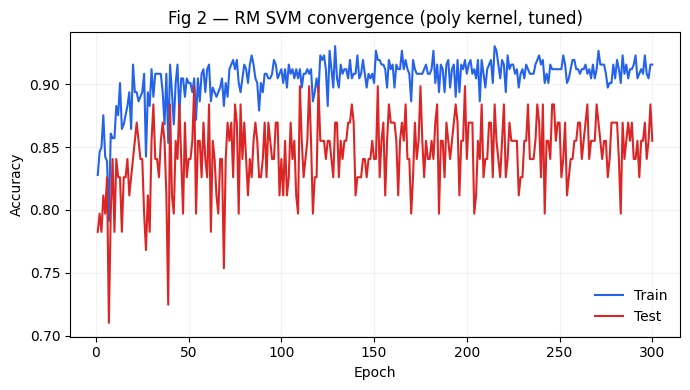

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, len(final['train_acc_history']) + 1)
ax.plot(epochs, final['train_acc_history'], label='Train', color='#2563eb', lw=1.5)
ax.plot(epochs, final['test_acc_history'],  label='Test',  color='#dc2626', lw=1.5)
ax.set(xlabel='Epoch', ylabel='Accuracy',
       title=f"Fig 2 — RM SVM convergence ({best['kernel']} kernel, tuned)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

---
## 4 Per-Kernel Final Evaluation

Refit the best RM configuration for **each** kernel on the full training set and evaluate on the test set. This gives a fair kernel-to-kernel comparison where each kernel uses its own best-tuned settings.

In [10]:
df = joint['results_df'].copy()
idx_best = df.groupby('kernel')['mean_cv'].idxmax()
per_kernel_best = df.loc[idx_best]

final_rows = []
for _, row in per_kernel_best.iterrows():
    res = fit_best(
        robbins_monro_svm,
        X_train, y_train_svm, X_test, y_test_svm,
        row.to_dict(), n_epochs_override=300,
    )
    y_p = predict_rm(res, X_test)
    final_rows.append({
        'Kernel':        row['kernel'],
        'Kernel Params': str(row['kernel_params']),
        'CV Acc':        f"{row['mean_cv']:.4f}",
        'Test Acc':      f"{(y_p == y_test).mean():.4f}",
        'Fit Time (s)':  f"{res['fit_time_s']:.2f}",
    })

final_df = pd.DataFrame(final_rows)
final_df.index = final_df.index + 1
final_df.index.name = '#'
final_df.style.set_caption('Table 4 — Per-kernel test performance (best-tuned RM settings, 300 epochs)')

,Kernel,Kernel Params,CV Acc,Test Acc,Fit Time (s)
#,,,,,
1,linear,{},0.7909,0.7826,0.24
2,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.8425,0.8551,0.20
3,rbf,{'gamma': 0.1},0.8242,0.8261,0.24
4,sigmoid,"{'gamma': 0.1, 'coef0': 0.0}",0.7359,0.8116,0.27


### Classification Reports

In [11]:
for _, row in per_kernel_best.iterrows():
    res = fit_best(
        robbins_monro_svm,
        X_train, y_train_svm, X_test, y_test_svm,
        row.to_dict(), n_epochs_override=300,
    )
    y_p = predict_rm(res, X_test)
    print_rm_eval_report(y_test, y_p, model_name=f"RM SVM — {row['kernel']}")
    print()

=== RM SVM — linear ===
Test Accuracy: 0.783

              precision    recall  f1-score   support

           0       0.76      0.83      0.79        35
           1       0.81      0.74      0.77        34

    accuracy                           0.78        69
   macro avg       0.78      0.78      0.78        69
weighted avg       0.78      0.78      0.78        69

Confusion Matrix:
[[29  6]
 [ 9 25]]

=== RM SVM — poly ===
Test Accuracy: 0.855

              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

Confusion Matrix:
[[33  2]
 [ 8 26]]

=== RM SVM — rbf ===
Test Accuracy: 0.826

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        35
           1       0.92     

---
## 5 Timing Comparison



In [12]:
print(f"Total joint CV search time: {joint['fit_time_s']:.1f}s")
print(f"Total configurations evaluated: {len(df)}")
print(f"Avg time per config (5-fold): {joint['fit_time_s'] / len(df):.3f}s")

Total joint CV search time: 419.7s
Total configurations evaluated: 1512
Avg time per config (5-fold): 0.278s


# AdaGrad SVM — Optimization

Soft-margin SVM using AdaGrad

in the dual/representer form with kernels.

**loss minimised:**

$$
L(\alpha,b)=\frac{1}{n}\sum_{j=1}^{n}\max\{0,\,1-y_j(K_j^\top \alpha-b)\}+\lambda\|w\|^2
$$

where $w=\sum_i \alpha_i \varphi(x_i)$ and $K$ is the Gram matrix for the chosen kernel.

AdaGrad uses the same objective as the Robbins–Monro SVM above,

but replaces the global decaying step-size with coordinate-wise adaptive learning rates:

$$
G_t=\sum_{s\le t} g_s^2,\qquad
\theta_{t+1}=\theta_t-\frac{\eta_0}{\sqrt{G_t+\varepsilon}}\,g_t
$$

## 1 Baseline: AdaGrad with Joint Kernel Search

In [13]:
ada_out = run_svm_experiments(
    adagrad_svm, ADAGRAD_PARAM_GRID,
    filepath="../data/ridings.csv",
    n_epochs_override=150,
    verbose=True,
)

  linear    combos tested:   36  best_cv so far: 0.7875  [12s]
  rbf       combos tested:  216  best_cv so far: 0.8242  [77s]
  poly      combos tested: 1188  best_cv so far: 0.8242  [432s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8242  [575s]


In [14]:
ada_best = ada_out["search"]["best_result"]

ada_df = pd.DataFrame([{
    "Kernel":        ada_best["kernel"],
    "Kernel Params": str(ada_best["kernel_params"]),
    "lambda_reg":    ada_best["lambda_reg"],
    "eta0":          ada_best["eta0"],
    "eps":           ada_best["eps"],
    "n_epochs":      ada_best["n_epochs"],
    "Mean CV":       round(ada_best["mean_cv"], 4),
    "Std CV":        round(ada_best["std_cv"], 4),
    "Test Acc":      round(ada_out["test_acc"], 4),
}])
ada_df.index = ada_df.index + 1
ada_df.index.name = "#"
ada_df.style.set_caption("Table — AdaGrad SVM best setting")

,Kernel,Kernel Params,lambda_reg,eta0,eps,n_epochs,Mean CV,Std CV,Test Acc
#,,,,,,,,,
1,poly,"{'degree': 3, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.100000,0.000000,50,0.824200,0.039100,0.855100


In [15]:
print_rm_eval_report(
    ada_out["data"]["y_test"],
    ada_out["y_pred"],
    model_name="AdaGrad SVM"
)

=== AdaGrad SVM ===
Test Accuracy: 0.855

              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

Confusion Matrix:
[[33  2]
 [ 8 26]]


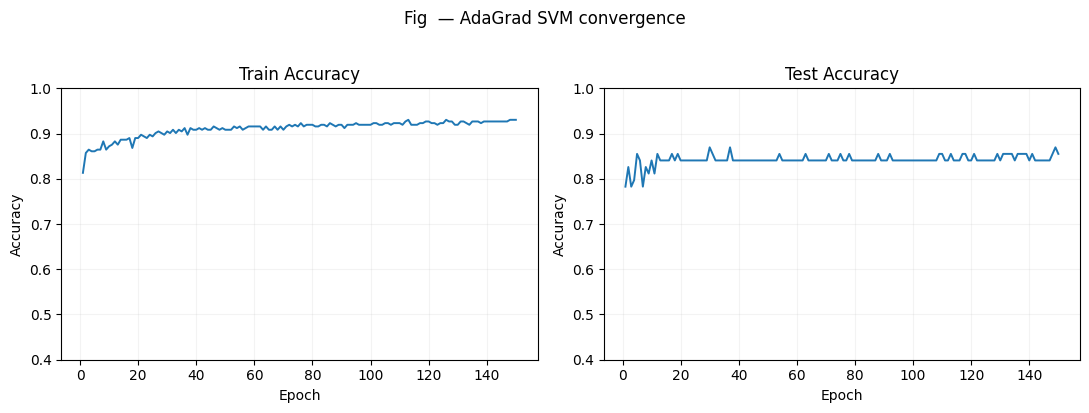

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, len(ada_out["fit"]["train_acc_history"]) + 1)

axes[0].plot(epochs, ada_out["fit"]["train_acc_history"], lw=1.4)
axes[1].plot(epochs, ada_out["fit"]["test_acc_history"], lw=1.4)

for ax, title in zip(axes, ['Train Accuracy', 'Test Accuracy']):
    ax.set(xlabel='Epoch', ylabel='Accuracy', title=title)
    ax.grid(True, alpha=0.15)
    ax.set_ylim(0.4, 1.0)

fig.suptitle('Fig  — AdaGrad SVM convergence', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 2 Comparison: RM vs AdaGrad

In [17]:
# pick the best RM baseline kernel by test accuracy
rm_rows = []
for k, res in baseline.items():
    rm_rows.append({
        "Kernel": k,
        "Kernel Params": str(res["kernel_params"]) if res["kernel_params"] else "—",
        "Train Acc": res["train_acc_history"][-1],
        "Test Acc": res["test_acc_history"][-1],
        "Time (s)": res["fit_time_s"],
    })

rm_baseline_df = pd.DataFrame(rm_rows)
rm_best_row = rm_baseline_df.sort_values("Test Acc", ascending=False).iloc[0]

ada_best = ada_out["search"]["best_result"]
rm_tuned_best = joint["best_result"]
comparison_df = pd.DataFrame([
    {
        "Algorithm": "RM baseline",
        "Kernel": rm_best_row["Kernel"],
        "Best CV": "—",
        "Test Acc": round(rm_best_row["Test Acc"], 4),
        "Notes": "Default hyperparameters",
    },
    {
        "Algorithm": "RM tuned",
        "Kernel": rm_tuned_best["kernel"],
        "Best CV": round(rm_tuned_best["mean_cv"], 4),
        "Test Acc": round(final["test_acc_history"][-1], 4),
        "Notes": "Joint kernel + RM tuning",
    },
    {
        "Algorithm": "AdaGrad SVM",
        "Kernel": ada_best["kernel"],
        "Best CV": round(ada_best["mean_cv"], 4),
        "Test Acc": round(ada_out["test_acc"], 4),
        "Notes": "Joint kernel + AdaGrad tuning",
    },
])

comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "#"
comparison_df.style.set_caption("Table — RM vs AdaGrad")

,Algorithm,Kernel,Best CV,Test Acc,Notes
#,,,,,
1,RM baseline,linear,—,0.797100,Default hyperparameters
2,RM tuned,poly,0.842500,0.855100,Joint kernel + RM tuning
3,AdaGrad SVM,poly,0.824200,0.855100,Joint kernel + AdaGrad tuning


AdaGrad fits the same kernelized soft-margin SVM framework as the Robbins–Monro baseline, but uses adaptive coordinate-wise learning rates instead of a single decaying global step size.

In our experiments, AdaGrad achieved competitive performance under the same kernelized setup and therefore serves as a natural optimizer comparison within the assignment framework.

---
# Adam SVM — Optimization

Soft-margin SVM using **Adaptive Moment Estimation (Adam)** in the dual/representer form with kernels.

Adam extends AdaGrad by maintaining exponentially decaying averages of both the gradient (first moment $m_t$) and the squared gradient (second moment $v_t$), with bias-correction to account for their zero-initialisation:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t, \qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2
$$
$$
\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^t}
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat v_t}+\varepsilon}\,\hat m_t
$$

The same kernelized SVM objective is minimised as for RM and AdaGrad.

## 1 Joint Kernel + Adam Search

In [18]:
adam_out = run_svm_experiments(
    adam_svm, ADAM_PARAM_GRID,
    filepath="../data/ridings.csv",
    n_epochs_override=150,
    verbose=True,
)

  linear    combos tested:   36  best_cv so far: 0.7910  [40s]
  rbf       combos tested:  216  best_cv so far: 0.8242  [236s]
  poly      combos tested: 1188  best_cv so far: 0.8280  [1425s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8280  [1803s]


In [19]:
adam_best = adam_out["search"]["best_result"]

adam_df = pd.DataFrame([{
    "Kernel":        adam_best["kernel"],
    "Kernel Params": str(adam_best["kernel_params"]),
    "lambda_reg":    adam_best["lambda_reg"],
    "lr":            adam_best["learning_rate"],
    "beta1":         adam_best["beta1"],
    "beta2":         adam_best["beta2"],
    "epsilon":       adam_best["epsilon"],
    "n_epochs":      adam_best["n_epochs"],
    "Mean CV":       round(adam_best["mean_cv"], 4),
    "Std CV":        round(adam_best["std_cv"], 4),
    "Test Acc":      round(adam_out["test_acc"], 4),
}])
adam_df.index = adam_df.index + 1
adam_df.index.name = "#"
adam_df.style.set_caption("Table — Adam SVM best setting")

,Kernel,Kernel Params,lambda_reg,lr,beta1,beta2,epsilon,n_epochs,Mean CV,Std CV,Test Acc
#,,,,,,,,,,,
1,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 10}",0.010000,0.000100,0.500000,0.999000,0.000000,100,0.828000,0.035200,0.855100


In [20]:
print_rm_eval_report(
    adam_out["data"]["y_test"],
    adam_out["y_pred"],
    model_name="Adam SVM",
)

=== Adam SVM ===
Test Accuracy: 0.855

              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

Confusion Matrix:
[[33  2]
 [ 8 26]]


## 2 Three-Way Comparison: RM vs AdaGrad vs Adam

In [21]:
comparison_df = pd.DataFrame([
    {
        "Algorithm": "Robbins-Monro",
        "Kernel":    joint["best_result"]["kernel"],
        "Best CV":   round(joint["best_result"]["mean_cv"], 4),
        "Test Acc":  round(final["test_acc_history"][-1], 4),
    },
    {
        "Algorithm": "AdaGrad",
        "Kernel":    ada_out["search"]["best_result"]["kernel"],
        "Best CV":   round(ada_out["search"]["best_result"]["mean_cv"], 4),
        "Test Acc":  round(ada_out["test_acc"], 4),
    },
    {
        "Algorithm": "Adam",
        "Kernel":    adam_out["search"]["best_result"]["kernel"],
        "Best CV":   round(adam_out["search"]["best_result"]["mean_cv"], 4),
        "Test Acc":  round(adam_out["test_acc"], 4),
    },
])
comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "#"
comparison_df.style.set_caption("Table — RM vs AdaGrad vs Adam (joint-tuned)")

,Algorithm,Kernel,Best CV,Test Acc
#,,,,
1,Robbins-Monro,poly,0.842500,0.855100
2,AdaGrad,poly,0.824200,0.855100
3,Adam,poly,0.828000,0.855100


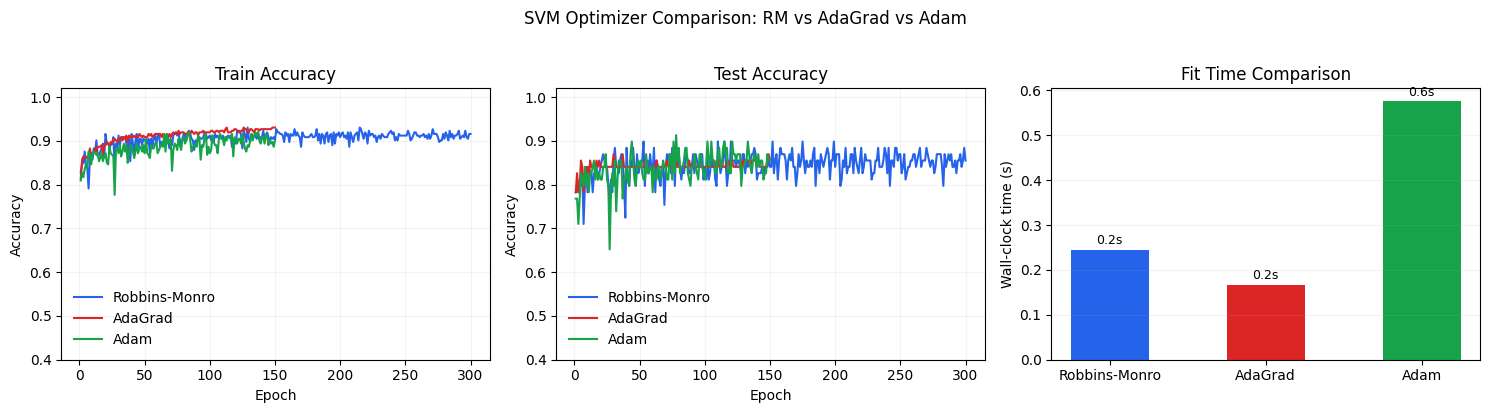

In [22]:
fits   = [final,          ada_out["fit"],  adam_out["fit"]]
colors = ["#2563eb",      "#dc2626",        "#16a34a"]
names  = ["Robbins-Monro", "AdaGrad",       "Adam"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train accuracy
ax = axes[0]
for fit, color, name in zip(fits, colors, names):
    ax.plot(range(1, len(fit["train_acc_history"]) + 1),
            fit["train_acc_history"], label=name, color=color, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Accuracy", title="Train Accuracy")
ax.legend(frameon=False); ax.grid(True, alpha=0.15); ax.set_ylim(0.4, 1.02)

# Test accuracy
ax = axes[1]
for fit, color, name in zip(fits, colors, names):
    ax.plot(range(1, len(fit["test_acc_history"]) + 1),
            fit["test_acc_history"], label=name, color=color, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Accuracy", title="Test Accuracy")
ax.legend(frameon=False); ax.grid(True, alpha=0.15); ax.set_ylim(0.4, 1.02)

# Wall-clock fit time
ax = axes[2]
times = [fit["fit_time_s"] for fit in fits]
bars  = ax.bar(names, times, color=colors, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(times) * 0.01,
            f"{t:.1f}s", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="Wall-clock time (s)", title="Fit Time Comparison")
ax.grid(True, alpha=0.15, axis="y")

fig.suptitle("SVM Optimizer Comparison: RM vs AdaGrad vs Adam", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()